In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (10,6)
sns.set_style("whitegrid")

In [20]:
df = pd.read_csv("job_postings_flat.csv")
print(df.shape)

(478895, 17)


### Data Cleaning
### Convert Date Column

In [ ]:
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

### Handle missing salaries

In [ ]:
df['salary_year_avg'] = pd.to_numeric(df['salary_year_avg'], errors='coerce')
df['salary_hour_avg'] = pd.to_numeric(df['salary_hour_avg'], errors='coerce')

### Analysing Missing Value percentages

In [ ]:
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_percent = missing_percent.sort_values(ascending=False)

print(missing_percent)
print(df.shape)

salary_hour_avg          97.895990
salary_year_avg          95.753766
salary_rate              93.649756
job_type_skills          14.381023
job_skills               14.381023
job_schedule_type         1.652137
job_location              0.286702
job_country               0.067029
company_name              0.001462
job_via                   0.001253
job_title                 0.000209
job_title_short           0.000000
job_work_from_home        0.000000
job_no_degree_mention     0.000000
job_posted_date           0.000000
search_location           0.000000
job_health_insurance      0.000000
dtype: float64
(478895, 17)


### Visualized Missing Value Percentage and deep analysis

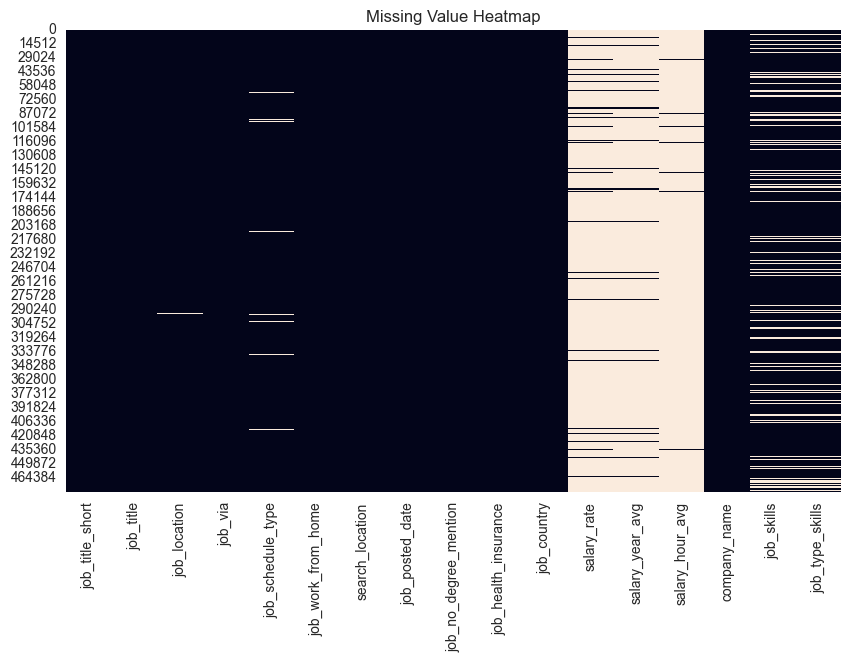

In [ ]:
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Value Heatmap")
plt.show()

### Key Insights:

* We find out that our core job metadata is highly complete. Although the salary column has missing data.
* This could be due to many people not wanting to disclose their data online leading to inconsistent salary data across data jobs.

### Created a meaningful segmentation of Salary Bands (Quantile Based)

In [ ]:
df_non_null = df.dropna(subset=['salary_year_avg']).copy()

df_non_null['salary_band'] = pd.qcut(
    df_non_null['salary_year_avg'],
    q=4,
    labels=['Low', 'Mid', 'High', 'Very High']
)

band_summary = df_non_null.groupby(
    'salary_band',observed=False)['salary_year_avg'].describe()
print(band_summary)
print(df.shape)

              count           mean           std       min       25%  \
salary_band                                                            
Low          5084.0   67553.981209  14297.972505   15000.0   60000.0   
Mid          5106.0  101069.403279   7700.122502   86000.0   95000.0   
High         5066.0  129281.611918   9670.254819  113257.5  121824.0   
Very High    5079.0  184624.963739  39838.375330  149617.5  159500.0   

                       50%       75%       max  
salary_band                                     
Low           72500.000000   77500.0   85950.0  
Mid          100000.000000  108415.5  113250.0  
High         128570.757812  136500.0  149589.0  
Very High    173500.000000  200000.0  920000.0  
(478895, 17)


### Calculated median salary and showed the median value 

In [ ]:
median_salary = np.nanmedian(df['salary_year_avg']) 

print(f"Median yearly salary (excluding missing values): {median_salary:,.2f}")

Median yearly salary (excluding missing values): 113,250.00


### Removed extreme salary outliers using IQR method to prevent distortion in statistical analysis

In [ ]:
Q1 = df['salary_year_avg'].quantile(0.25)
Q3 = df['salary_year_avg'].quantile(0.75)
IQR = Q3 - Q1

print(f"""
Q1 (25th percentile): {Q1:,.2f}
Q3 (75th percentile): {Q3:,.2f}
IQR: {IQR:,.2f}
""")


Q1 (25th percentile): 85,975.00
Q3 (75th percentile): 149,589.00
IQR: 63,614.00



### Skewness Check For The Data Jobs Salary

In [ ]:
skewness = df['salary_year_avg'].skew()
print("Salary Skewness:", skewness)

Salary Skewness: 1.542203897092446


### Key Insights:

* Salary Skewness > 1
* Which shows that it is highly right skewed
* Which justifies using Median instead of Mean (which is often the case with Job Salaries)

### Finding out the Standard Deviation & Variance. Showing the Salary Dispersion 

In [ ]:
salary_std = np.std(df['salary_year_avg'])
salary_var = np.var(df['salary_year_avg'])

print(f"Standard Deviation: {salary_std:,.2f}")
print(f"Variance: {salary_var:,.2f}")

Standard Deviation: 48,244.21
Variance: 2,327,504,067.88


### Key Insights:

* A standard deviation of 48k means: On average, salaries deviate about $48,000 from the mean salary.
* This indicates significant salary dispersion within the global data job market, likely driven by differences in experience levels,specialization, and country-based pay structures.

### Found the Mean Salary and the Coefficient of Variation 

* This is to find out how much the salaries vary from the global average
* Whether it has a high or low dispersion

In [ ]:
mean_salary = df['salary_year_avg'].mean()
print(f"Mean Salary: {mean_salary:,.2f}")
cv = (df['salary_year_avg'].std() / mean_salary) * 100
print(f"Coefficient of Variation: {cv:.2f}%")

Mean Salary: 120,587.93
Coefficient of Variation: 40.01%


### Key Insights:

* This shows salaries vary by about 40% of the average salary. Indicating a very high dispersion in the compensation structure
* The salary distribution exhibits high variability (CV = 40%), indicating significant pay dispersion across roles and geographies.
* This suggests the global data job market contains distinct salary tiers rather than a uniform compensation structure
* Hence,the median salary becomes more reliable than the mean for describing “typical pay”
* This coupled with the right skewness suggests that a couple of very high salaries is affecting the average salaries
* Hence, the median salary is a much better indicator of the global typical salary in the data jobs

### Final Insight

* The global data job market exhibits a highly right-skewed salary distribution (skewness > 1)
* With substantial dispersion (SD ≈ $48k; CV = 40%), indicating significant inequality in compensation across roles and geographies
* The high variability and presence of extreme high-paying roles inflate the mean salary, making the median a more reliable measure of typical compensation. 
* This suggests that the market operates in distinct salary tiers rather than as a uniform pay structure